# EMERALDS Trades Visualization (Days -2 and -1)

Single-chart view of all EMERALDS trades from round 0 trade files.

- Price axis is centered around 10000
- Color intensity maps to trade quantity (darker = larger)
- Days are separated along the x-axis

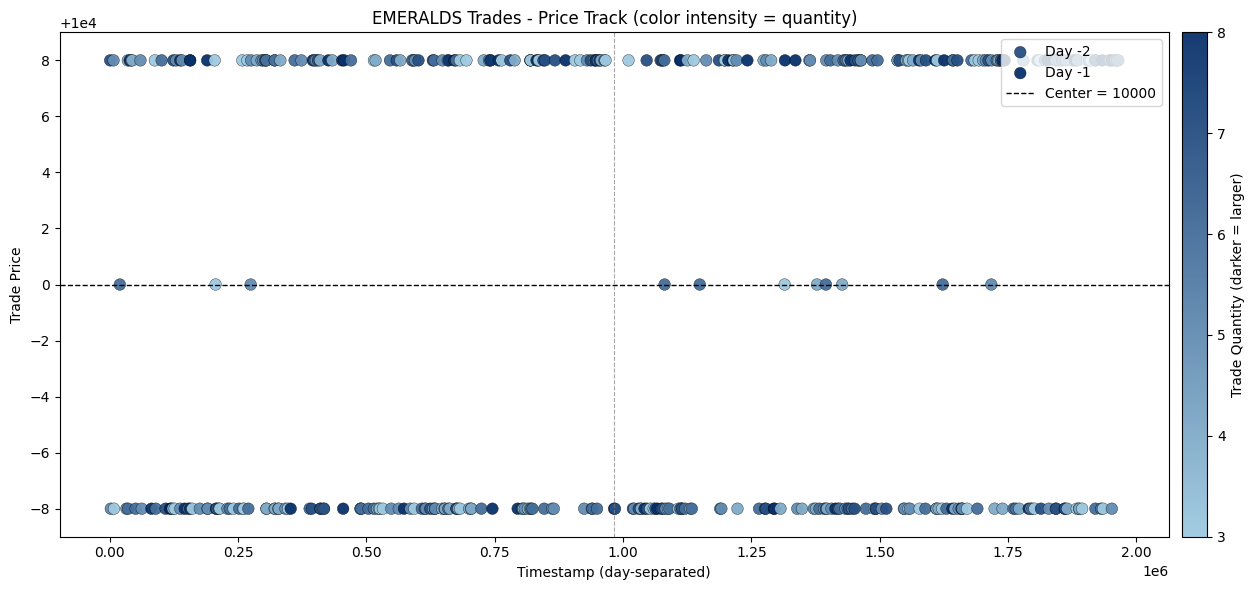

EMERALDS trades loaded: 399
Days included: [np.int64(-2), np.int64(-1)]
Price range: 9992.0 to 10008.0
Centered y-limits used: [9991, 10009]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

DATA_DIR = "../TUTORIAL_ROUND_1"
DAY_COLORS = {-2: "#1f77b4", -1: "#ff7f0e"}

# Load and combine trades for day -2 and -1
trade_dfs = []
for day in [-2, -1]:
    tdf = pd.read_csv(f"{DATA_DIR}/trades_round_0_day_{day}.csv", sep=";")
    tdf["day"] = day
    trade_dfs.append(tdf)
trades = pd.concat(trade_dfs, ignore_index=True)

# Keep EMERALDS only and clean sort order
emerald_trades = (
    trades[trades["symbol"] == "EMERALDS"]
    .copy()
    .sort_values(["day", "timestamp"])
)

# Day-separated x-axis
days_t = sorted(emerald_trades["day"].unique())
ts_min_t = emerald_trades["timestamp"].min()
ts_span_t = emerald_trades["timestamp"].max() - ts_min_t + 1
day_offset_t = {day: i * ts_span_t for i, day in enumerate(days_t)}

emerald_trades["x"] = (
    emerald_trades["timestamp"] - ts_min_t + emerald_trades["day"].map(day_offset_t)
)

# Center y-axis around 10000 with symmetric bounds
CENTER_PRICE = 10000
max_dev = (emerald_trades["price"] - CENTER_PRICE).abs().max()
y_pad = max(1, int(np.ceil(max_dev + 1)))
ymin, ymax = CENTER_PRICE - y_pad, CENTER_PRICE + y_pad

# Quantity-to-color mapping: lighter for small, darker for large (kept legible)
qmin, qmax = emerald_trades["quantity"].min(), emerald_trades["quantity"].max()
qty_cmap = LinearSegmentedColormap.from_list("qty_blue", ["#9ecae1", "#08306b"])

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

for day in days_t:
    sub = emerald_trades[emerald_trades["day"] == day]
    sc = ax.scatter(
        sub["x"], sub["price"],
        c=sub["quantity"], cmap=qty_cmap, vmin=qmin, vmax=qmax,
        s=70, alpha=0.95,
        marker="o",
        edgecolor="black", linewidth=0.25,
        label=f"Day {day}"
    )

ax.axhline(CENTER_PRICE, color="black", lw=1.0, linestyle="--", label="Center = 10000")
ax.axvline(ts_span_t, color="gray", lw=0.8, linestyle="--", alpha=0.7)
ax.set_ylim(ymin, ymax)
ax.set_ylabel("Trade Price")
ax.set_xlabel("Timestamp (day-separated)")
ax.set_title("EMERALDS Trades - Price Track (color intensity = quantity)")
ax.legend(loc="upper right")

cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label("Trade Quantity (darker = larger)")

plt.tight_layout()
plt.show()

print(f"EMERALDS trades loaded: {len(emerald_trades)}")
print(f"Days included: {days_t}")
print(f"Price range: {emerald_trades['price'].min()} to {emerald_trades['price'].max()}")
print(f"Centered y-limits used: [{ymin}, {ymax}]")